# Forecast Layer Inspection

This notebook explains the WikiTrend forecasting layer built from `gold.hourly_project_access`. It is read-only: it loads generated Parquet outputs, compares the forecast models, and visualizes rolling-window backtests plus the next 24-hour forecasts.

Forecast scope remains the project scope: 72 hourly observations per series, grouped by `project` and `access_mode`.

## What The Forecast Layer Contains

The forecast builder writes these files under `data/processed/forecast/hourly_project_access/`:

| File | Meaning |
| --- | --- |
| `features.parquet` | one clean hourly time-series row per `project` and `access_mode` |
| `backtest_predictions.parquet` | rolling-window validation predictions for all models |
| `metrics.parquet` | MAE, RMSE, and sMAPE by model and series |
| `forecast.parquet` | next 24-hour predictions from the latest available Gold data |
| `forecast_manifest.json` | run metadata and model settings |

Models compared: `seasonal_naive_24h`, `ridge_lag`, `elasticnet_lag`, and `lightgbm_lag`. Regression models use per-series scale-normalized lag, rolling median, and rolling standard-deviation features. They train on `log1p(y / rolling_median_positive_series_scale)`, then convert predictions back to pageview counts.

In [1]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

ROOT = Path.cwd().resolve()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent.resolve()

FORECAST_DIR = ROOT / "data" / "processed" / "forecast" / "hourly_project_access"

FEATURES_PATH = FORECAST_DIR / "features.parquet"
BACKTEST_PATH = FORECAST_DIR / "backtest_predictions.parquet"
METRICS_PATH = FORECAST_DIR / "metrics.parquet"
FORECAST_PATH = FORECAST_DIR / "forecast.parquet"
MANIFEST_PATH = FORECAST_DIR / "forecast_manifest.json"

required_paths = [FEATURES_PATH, BACKTEST_PATH, METRICS_PATH, FORECAST_PATH, MANIFEST_PATH]
missing = [path for path in required_paths if not path.exists()]
if missing:
    raise FileNotFoundError(
        "Forecast outputs are missing. Run: python -m wikitrend.cli.build_forecast_pageviews\n"
        + "\n".join(str(path) for path in missing)
    )

features = pd.read_parquet(FEATURES_PATH)
backtest = pd.read_parquet(BACKTEST_PATH)
metrics = pd.read_parquet(METRICS_PATH)
forecast = pd.read_parquet(FORECAST_PATH)
manifest = json.loads(MANIFEST_PATH.read_text(encoding="utf-8"))

for frame in (features, backtest, forecast):
    frame["ds"] = pd.to_datetime(frame["ds"])

print(f"Forecast directory: {FORECAST_DIR}")
print(f"Feature rows: {len(features):,}")
print(f"Backtest prediction rows: {len(backtest):,}")
print(f"Future forecast rows: {len(forecast):,}")
print(f"Metric rows: {len(metrics):,}")

Forecast directory: D:\Tâm-WikiTrend\data\processed\forecast\hourly_project_access
Feature rows: 504
Backtest prediction rows: 1,008
Future forecast rows: 672
Metric rows: 32


## Run Manifest

Start here to understand exactly what was generated: number of series, folds, forecast horizon, models, and rolling-window settings.

In [2]:
pd.Series(manifest).to_frame("value")

,value
manifest_version,1
generated_at_utc,2026-08-26T02:11:25+00:00
source_table,hourly_project_access
target,total_views
target_transform,log1p(y / rolling_median_positive_series_scale)
feature_normalization,lag and rolling features include per-series sc...
grain,"hour, project, access_mode"
models,"[seasonal_naive_24h, ridge_lag, elasticnet_lag..."
forecast_dir,data\processed\forecast\hourly_project_access
feature_rows,504


## Data Scope

Each time series is one `project` + `access_mode` pair. With 72 hours of data and 7 series, the feature table should have 504 rows.

In [3]:
series_scope = (
    features.groupby(["project", "access_mode"])
    .agg(
        rows=("y", "size"),
        start=("ds", "min"),
        end=("ds", "max"),
        total_views=("y", "sum"),
        avg_hourly_views=("y", "mean"),
        max_hourly_views=("y", "max"),
    )
    .reset_index()
    .sort_values("total_views", ascending=False)
)
series_scope

,project,access_mode,rows,start,end,total_views,avg_hourly_views,max_hourly_views
3,en,mobile,72,2026-01-01,2026-01-03 23:00:00,513735205.0,7.135211e+06,9401263.0
2,en,desktop,72,2026-01-01,2026-01-03 23:00:00,222927754.0,3.096219e+06,4375963.0
0,commons,desktop,72,2026-01-01,2026-01-03 23:00:00,9795529.0,1.360490e+05,213380.0
1,commons,mobile,72,2026-01-01,2026-01-03 23:00:00,4739553.0,6.582712e+04,120651.0
5,vi,mobile,72,2026-01-01,2026-01-03 23:00:00,2933827.0,4.074760e+04,69117.0
6,wikidata,desktop,72,2026-01-01,2026-01-03 23:00:00,2110030.0,2.930597e+04,39103.0
4,vi,desktop,72,2026-01-01,2026-01-03 23:00:00,1309708.0,1.819039e+04,38937.0


## Model Leaderboard

Lower `mdae`, `mase`, `rmase`, `mdape`, and `mdsmape` are better. `rmase < 1.0` means the model beat the seasonal naive baseline for the same evaluation slice. The `__all__` rows show overall model performance across every series and rolling fold.

In [4]:
overall_metrics = (
    metrics.query("project == '__all__' and access_mode == '__all__'")
    .sort_values("rmase")
    .reset_index(drop=True)
)
overall_metrics[["model", "folds", "observations", "mdae", "mase", "rmase", "mdape", "mdsmape"]]

,model,folds,observations,mdae,mase,rmase,mdape,mdsmape
0,seasonal_naive_24h,21,252,7167.000000,0.943352,1.000000,9.901751,10.104841
1,elasticnet_lag,21,252,9731.103224,1.057848,1.121372,13.381053,14.104591
2,lightgbm_lag,21,252,11551.470651,1.166847,1.236916,14.783936,15.093253
3,ridge_lag,21,252,12611.251775,1.298981,1.376985,14.964560,15.939248


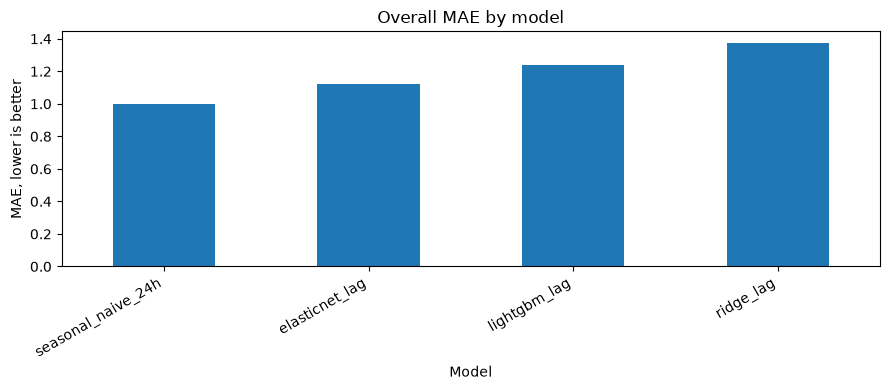

In [5]:
ax = overall_metrics.plot.bar(
    x="model",
    y="rmase",
    legend=False,
    figsize=(9, 4),
    title="Overall MAE by model",
)
ax.set_xlabel("Model")
ax.set_ylabel("MAE, lower is better")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()

## Best Model By Series

This table shows which model wins for each project/access-mode series by MAE. With only 72 hours of data, a simple seasonal baseline can be difficult for machine-learning models to beat.

In [6]:
series_metrics = metrics.query("project != '__all__'").copy()
best_by_series = (
    series_metrics.sort_values(["project", "access_mode", "rmase"])
    .groupby(["project", "access_mode"], as_index=False)
    .first()
)
best_by_series[["project", "access_mode", "model", "mdae", "mase", "rmase", "mdape", "mdsmape"]]

,project,access_mode,model,mdae,mase,rmase,mdape,mdsmape
0,commons,desktop,lightgbm_lag,16316.967118,0.690176,0.670392,11.701393,12.428551
1,commons,mobile,ridge_lag,8854.586741,1.092798,0.609572,12.420987,11.694361
2,en,desktop,seasonal_naive_24h,296406.500000,0.228572,1.000000,10.132348,10.104841
3,en,mobile,elasticnet_lag,355289.742156,1.495652,0.982094,5.561515,5.408382
4,vi,desktop,seasonal_naive_24h,2155.500000,0.703921,1.000000,12.468831,13.297989
5,vi,mobile,seasonal_naive_24h,1009.000000,0.818359,1.000000,4.982146,5.110935
6,wikidata,desktop,lightgbm_lag,2696.786189,0.736429,0.878394,9.038619,8.930702


In [7]:
pivot_rmase = series_metrics.pivot_table(
    index=["project", "access_mode"],
    columns="model",
    values="rmase",
    aggfunc="first",
).sort_index()
pivot_rmase

model                 elasticnet_lag  lightgbm_lag  ridge_lag  \
project  access_mode                                            
commons  desktop            0.792085      0.670392   1.848920   
         mobile             0.767688      0.873489   0.609572   
en       desktop            3.468162      4.594504   2.975294   
         mobile             0.982094      3.878081   0.985505   
vi       desktop            1.302554      2.431668   1.787665   
         mobile             5.281423      4.617717   5.654251   
wikidata desktop            0.939931      0.878394   1.062890   

model                 seasonal_naive_24h  
project  access_mode                      
commons  desktop                     1.0  
         mobile                      1.0  
en       desktop                     1.0  
         mobile                      1.0  
vi       desktop                     1.0  
         mobile                      1.0  
wikidata desktop                     1.0

## Rolling-Window Backtest

The default split uses 36 hours for training, forecasts the next 12 hours, then moves the window forward by 12 hours. With 72 hours, each series gets 3 validation folds.

In [8]:
folds = (
    backtest.groupby(["project", "access_mode", "fold_id"])
    .agg(
        validation_start=("ds", "min"),
        validation_end=("ds", "max"),
        horizon_steps=("horizon_step", "max"),
    )
    .reset_index()
    .sort_values(["project", "access_mode", "fold_id"])
)
folds.head(21)

,project,access_mode,fold_id,validation_start,validation_end,horizon_steps
0,commons,desktop,1,2026-01-02 12:00:00,2026-01-02 23:00:00,12
1,commons,desktop,2,2026-01-03 00:00:00,2026-01-03 11:00:00,12
2,commons,desktop,3,2026-01-03 12:00:00,2026-01-03 23:00:00,12
3,commons,mobile,4,2026-01-02 12:00:00,2026-01-02 23:00:00,12
4,commons,mobile,5,2026-01-03 00:00:00,2026-01-03 11:00:00,12
5,commons,mobile,6,2026-01-03 12:00:00,2026-01-03 23:00:00,12
6,en,desktop,7,2026-01-02 12:00:00,2026-01-02 23:00:00,12
7,en,desktop,8,2026-01-03 00:00:00,2026-01-03 11:00:00,12
8,en,desktop,9,2026-01-03 12:00:00,2026-01-03 23:00:00,12
9,en,mobile,10,2026-01-02 12:00:00,2026-01-02 23:00:00,12


## Pick One Series To Inspect

Change these two values to focus on a different time series.

In [9]:
available_series = (
    features[["project", "access_mode"]]
    .drop_duplicates()
    .sort_values(["project", "access_mode"])
    .reset_index(drop=True)
)
available_series

,project,access_mode
0,commons,desktop
1,commons,mobile
2,en,desktop
3,en,mobile
4,vi,desktop
5,vi,mobile
6,wikidata,desktop


In [10]:
CHOSEN_PROJECT = best_by_series.iloc[0]["project"]
CHOSEN_ACCESS_MODE = best_by_series.iloc[0]["access_mode"]

print(f"Selected series: {CHOSEN_PROJECT} / {CHOSEN_ACCESS_MODE}")

Selected series: commons / desktop


## Historical Actuals

This chart shows the 72-hour actual series that all models train and validate on.

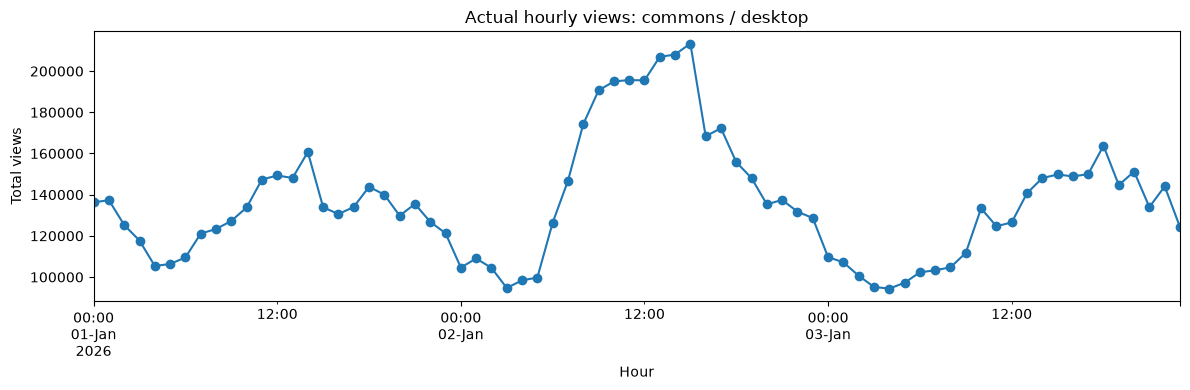

In [11]:
selected_features = features.query(
    "project == @CHOSEN_PROJECT and access_mode == @CHOSEN_ACCESS_MODE"
).sort_values("ds")

ax = selected_features.plot(
    x="ds",
    y="y",
    figsize=(12, 4),
    marker="o",
    title=f"Actual hourly views: {CHOSEN_PROJECT} / {CHOSEN_ACCESS_MODE}",
    legend=False,
)
ax.set_xlabel("Hour")
ax.set_ylabel("Total views")
plt.tight_layout()

## Backtest: Actual vs Predicted

This plot overlays every model's rolling-window predictions against the actual validation values for the selected series.

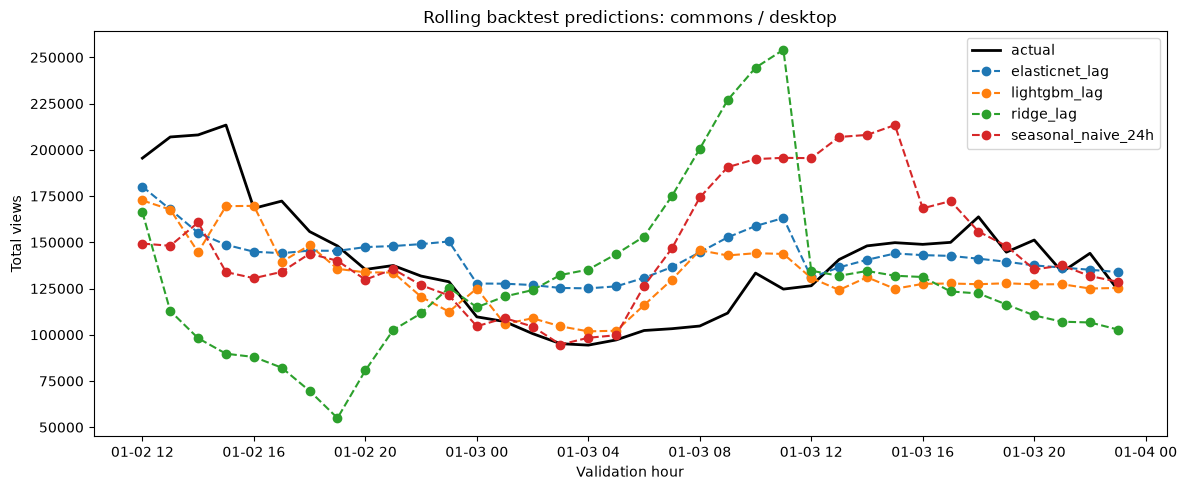

In [12]:
selected_backtest = backtest.query(
    "project == @CHOSEN_PROJECT and access_mode == @CHOSEN_ACCESS_MODE"
).sort_values(["model", "fold_id", "horizon_step"])

actual = selected_backtest[["ds", "y_true"]].drop_duplicates().sort_values("ds")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(actual["ds"], actual["y_true"], label="actual", color="black", linewidth=2)
for model, group in selected_backtest.groupby("model"):
    ordered = group.sort_values("ds")
    ax.plot(ordered["ds"], ordered["y_pred"], marker="o", linestyle="--", label=model)
ax.set_title(f"Rolling backtest predictions: {CHOSEN_PROJECT} / {CHOSEN_ACCESS_MODE}")
ax.set_xlabel("Validation hour")
ax.set_ylabel("Total views")
ax.legend()
plt.tight_layout()

## Backtest Errors

Use this table to see where each model over-predicted or under-predicted during validation.

In [13]:
error_table = selected_backtest.copy()
error_table["error"] = error_table["y_pred"] - error_table["y_true"]
error_table["absolute_error"] = error_table["error"].abs()
error_table.sort_values("absolute_error", ascending=False).head(20)

,fold_id,horizon_step,ds,project,access_mode,model,y_true,y_pred,mase_scale,error,absolute_error
71,2,12,2026-01-03 11:00:00,commons,desktop,ridge_lag,124688.0,254109.712801,24871.5,129421.712801,129421.712801
15,1,4,2026-01-02 15:00:00,commons,desktop,ridge_lag,213380.0,89743.674589,26968.0,-123636.325411,123636.325411
69,2,10,2026-01-03 09:00:00,commons,desktop,ridge_lag,111717.0,226920.251812,24871.5,115203.251812,115203.251812
70,2,11,2026-01-03 10:00:00,commons,desktop,ridge_lag,133341.0,244403.246354,24871.5,111062.246354,111062.246354
14,1,3,2026-01-02 14:00:00,commons,desktop,ridge_lag,208061.0,98119.909724,26968.0,-109941.090276,109941.090276
68,2,9,2026-01-03 08:00:00,commons,desktop,ridge_lag,104725.0,200571.629194,24871.5,95846.629194,95846.629194
13,1,2,2026-01-02 13:00:00,commons,desktop,ridge_lag,206947.0,112865.150294,26968.0,-94081.849706,94081.849706
19,1,8,2026-01-02 19:00:00,commons,desktop,ridge_lag,148024.0,54946.589466,26968.0,-93077.410534,93077.410534
17,1,6,2026-01-02 17:00:00,commons,desktop,ridge_lag,172284.0,82192.014693,26968.0,-90091.985307,90091.985307
18,1,7,2026-01-02 18:00:00,commons,desktop,ridge_lag,155803.0,69642.625402,26968.0,-86160.374598,86160.374598


## Future 24-Hour Forecast

This chart combines the last 72 hours of actuals with the next 24 hours of model forecasts.

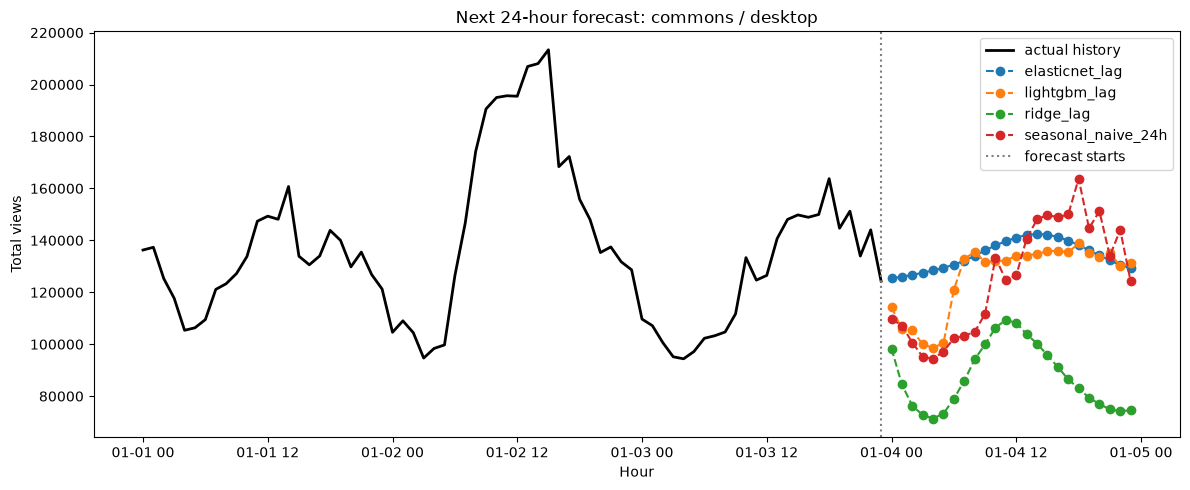

In [14]:
selected_forecast = forecast.query(
    "project == @CHOSEN_PROJECT and access_mode == @CHOSEN_ACCESS_MODE"
).sort_values(["model", "horizon_step"])

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(
    selected_features["ds"],
    selected_features["y"],
    label="actual history",
    color="black",
    linewidth=2,
)
for model, group in selected_forecast.groupby("model"):
    ax.plot(group["ds"], group["yhat"], marker="o", linestyle="--", label=model)
ax.axvline(selected_features["ds"].max(), color="gray", linestyle=":", label="forecast starts")
ax.set_title(f"Next 24-hour forecast: {CHOSEN_PROJECT} / {CHOSEN_ACCESS_MODE}")
ax.set_xlabel("Hour")
ax.set_ylabel("Total views")
ax.legend()
plt.tight_layout()

## Interpretation Notes

Use this checklist when reading the results:

1. If `seasonal_naive_24h` wins, the data is mostly repeating a daily pattern and the 72-hour window is too short for complex models.
2. If `lightgbm_lag` wins on a series, lag and rolling features are adding useful signal beyond yesterday's value.
3. If `elasticnet_lag` beats `ridge_lag`, sparse lag selection is helping control overfit in the short window.
4. If `ridge_lag` performs poorly, the relationship is likely nonlinear or unstable within the short window.
5. Treat the future forecast as a pipeline demonstration, not a high-confidence production forecast, because the current training history is only 72 hours.